Step 1 — Load data & create sentiment labels

In [25]:
import tensorflow as tf
import random, os
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [26]:
import pandas as pd

df = pd.read_csv("../data/cleaned_data.csv")

# Drop rows where cleaning left nothing behind
df = df.dropna(subset=["clean_review"]).reset_index(drop=True)

# Derive sentiment from star rating
def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

print(df["sentiment"].value_counts())
print(f"\nTotal usable reviews: {len(df)}")

sentiment
negative    2221
positive    1590
neutral      319
Name: count, dtype: int64

Total usable reviews: 4130


Step 2 — Encode labels & split data

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])
print(dict(zip(le.classes_, le.transform(le.classes_))))  # check the mapping

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

{'negative': 0, 'neutral': 1, 'positive': 2}
Train: 3304 | Test: 826


Step 3 — Model 1: Naive Bayes (classic ML baseline)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Naive Bayes Results ===
Accuracy: 0.7869
              precision    recall  f1-score   support

    negative       0.73      0.96      0.83       444
     neutral       0.00      0.00      0.00        64
    positive       0.91      0.70      0.79       318

    accuracy                           0.79       826
   macro avg       0.55      0.55      0.54       826
weighted avg       0.75      0.79      0.75       826



c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


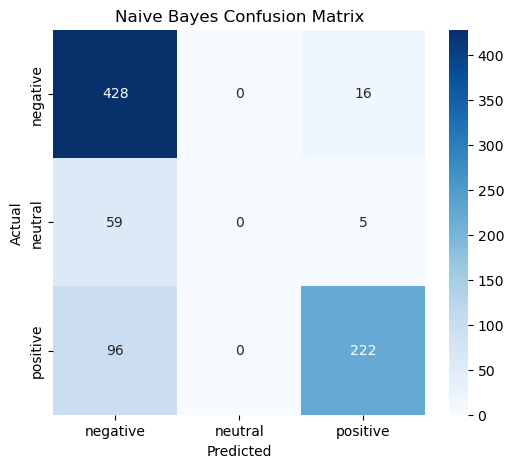

In [29]:
## Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.savefig("../reports/cm_naive_bayes.png", dpi=150, bbox_inches="tight")
plt.show()

Step 4 — Model 2: LSTM (deep learning)

In [30]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

MAX_VOCAB = 5000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, 
                            padding="post", truncating="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, 
                           padding="post", truncating="post")

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Compensate for the neutral class being small
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: 0.6197711498780717, 1: 4.318954248366013, 2: 0.8658280922431866}


In [31]:
## To Build and train

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

lstm_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

lstm_model.summary()

Epoch 1/15


c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.3414 - loss: 1.1003 - val_accuracy: 0.0906 - val_loss: 1.1065
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.3269 - loss: 1.0993 - val_accuracy: 0.5438 - val_loss: 1.0874
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.3690 - loss: 1.1009 - val_accuracy: 0.3867 - val_loss: 1.0884
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5668 - loss: 1.0052 - val_accuracy: 0.7462 - val_loss: 0.9272
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6815 - loss: 0.9025 - val_accuracy: 0.7462 - val_loss: 0.9153
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.6889 - loss: 0.8735 - val_accuracy: 0.7704 - val_loss: 0.8930
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7249 - loss: 0.8671 - val_accuracy: 0.7795 - val_loss: 0.8843
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7679 - loss: 0.8569 - val_accuracy: 0.7704 - val_loss: 0

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,074,763 (7.91 MB)

 Trainable params: 691,587 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,383,176 (5.28 MB)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
=== LSTM Results ===
Accuracy: 0.7663
              precision    recall  f1-score   support

    negative       0.72      0.95      0.82       444
     neutral       0.00      0.00      0.00        64
    positive       0.89      0.66      0.76       318

    accuracy                           0.77       826
   macro avg       0.54      0.54      0.53       826
weighted avg       0.73      0.77      0.73       826



c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


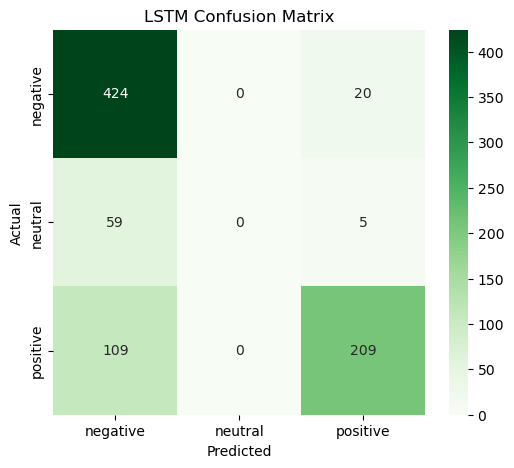

In [32]:
## To evaluate the model

y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)

print("=== LSTM Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.savefig("../reports/cm_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

Step 5 — Save the better model

In [33]:
import joblib

joblib.dump(nb_model, "../models/naive_bayes_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
lstm_model.save("../models/lstm_model.keras")
joblib.dump(tokenizer, "../models/lstm_tokenizer.pkl")
joblib.dump(le, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']